# Task 2 - Streaming Application

This notebook implements the streaming pipeline for the AWAS traffic mnonitoring system, which covers Kafka stream ingestion, stream-to-static joins with camera metadata, violation detection (average and instantaneous), and MongoDB sink integration.

Pipeline:
1. Ingesting camera event streams from Kafka through Producers A, B, C which each reads data from camera-events-A, camera-events-B, and camera-events-C respectively.
2. Joining each stream with camera metadata to retrieve speed limit, position, and coordinates
3. Detecting instantaneous violations, vehicles whose recorded speed exceeds the camera's speed limit will be flagged
4. Detecting average speed violations, by joniing entry and exit events then calculating the average speed, we can check if the speed limit has been breached (Road A->B and Road B->C)
5. Pushing all violations to MongoDB, grouped by car plate and violation date

### Environment Setup + Spark


In [1]:
import glob
import os
import shutil
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-streaming-kafka-0-10_2.12:3.3.0,org.apache.spark:spark-sql-kafka-0-10_2.12:3.3.0 pyspark-shell'

from pathlib import Path
from pymongo import MongoClient, UpdateOne
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql.functions import (
    col, expr, from_json, to_timestamp, abs as spark_abs,
    unix_timestamp, lit, to_date, sin, cos, sqrt, atan2, radians
)
from pyspark.sql.types import *
from datetime import datetime
import time

HOST_IP = "192.168.64.1"
MONGO_URI = "mongodb://mongodb:27017/"
MONGO_DB = "fit3182_a2"

spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('FIT3182-A2')
    .config("spark.sql.shuffle.partitions", "5")
    .config("spark.streaming.stopGracefullyOnShutdown", "true")
    .getOrCreate()
)

print("Debug: SparkSession has been created successfully.")

def log_batch(name):

    def logger(batch_df, batch_id):

        now = datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )

        row_count = batch_df.count()

        print("\n" + "=" * 70)
        print(f"[{now}] {name}")
        print(f"Spark Batch ID: {batch_id}")
        print(f"Rows received: {row_count}")
        print("=" * 70)

        batch_df.show(
            truncate=False
        )

    return logger

Debug: SparkSession has been created successfully.


## Watermark Calculation

In [2]:
import pandas as pd

df_a = pd.read_csv(f"{Path('..')}/data/camera_event_A.csv")
df_b = pd.read_csv(f"{Path('..')}/data/camera_event_B.csv")
df_c = pd.read_csv(f"{Path('..')}/data/camera_event_C.csv")
df_a["timestamp"] = pd.to_datetime(df_a["timestamp"])
df_b["timestamp"] = pd.to_datetime(df_b["timestamp"])
df_c["timestamp"] = pd.to_datetime(df_c["timestamp"])

a_timestamp = df_a["timestamp"].cummax()
a_diff = (df_a["timestamp"] - a_timestamp).dt.total_seconds()
a_diff.min() # Minimum time difference to get the latest timestamp for watermarking
camera_a_watermark = round(-a_diff.min() + 0.5) # ensure always round up to the nearest second
print(f"largest gap between an out-of-order event and the maximum timestamp for camera_event_A: {camera_a_watermark} seconds")

b_timestamp = df_b["timestamp"].cummax()
b_diff = (df_b["timestamp"] - b_timestamp).dt.total_seconds()
b_diff.min() # Minimum time difference to get the latest timestamp for watermarking
camera_b_watermark = round(-b_diff.min() + 0.5) # ensure always round up to the nearest second
print(f"largest gap between an out-of-order event and the maximum timestamp for camera_event_B: {camera_b_watermark} seconds")

c_timestamp = df_c["timestamp"].cummax()
c_diff = (df_c["timestamp"] - c_timestamp).dt.total_seconds()
c_diff.min() # Minimum time difference to get the latest timestamp for watermarking
camera_c_watermark = round(-c_diff.min() + 0.5) # ensure always round up to the nearest second
print(f"largest gap between an out-of-order event and the maximum timestamp for camera_event_C: {camera_c_watermark} seconds")

largest gap between an out-of-order event and the maximum timestamp for camera_event_A: 6 seconds
largest gap between an out-of-order event and the maximum timestamp for camera_event_B: 647 seconds
largest gap between an out-of-order event and the maximum timestamp for camera_event_C: 1834 seconds


## Task 2.1.2 Stream Ingestion
Each Kafka topic (camera-events-A/B/C) will be mapped to one producer, its events are then consumed as JSON and parsed against a fixed schema, while also being watermarked to bound the join window.

Event Schema:

| Field | Type | Description |
|---|---|---|
| `event_id` | String | Unique identifier for the camera event |
| `batch_id` | Integer | Producer batch sequence number |
| `car_plate` | String | Vehicle licence plate |
| `camera_id` | Integer | Camera that recorded the event |
| `timestamp` | String | ISO timestamp of the recording |
| `speed_reading` | Double | Recorded speed in km/h |

### Watermarking
Each stream has independent watermarks which have been precalculated based on the data. This preprocessing calculation calculates across the entire csv (data) what the largest gap between an out-of-order event and the maximum timestamp Spark had seen before it arrives. This ensures that no valid event is incorreclty dropped by Spark's late-arrival policy. Since the watermark is tight enough to tolerate the absolute worst-case out-of-order arrival in each stream without being large, which can cause state to accumulate in memory longer than needed if not configured properly.


In [3]:

# Create a JSON schema that matches the payload from producer for easier handling

event_schema = StructType([
    StructField("event_id", StringType()),
    StructField("batch_id", IntegerType()),
    StructField("car_plate", StringType()),
    StructField("camera_id", IntegerType()),
    StructField("timestamp", StringType()),
    StructField("speed_reading", DoubleType())
])

def read_camera_stream(topic, producer, watermark_time):
    return (
        spark.readStream
        .format("kafka")
        .option("kafka.bootstrap.servers", f"kafka:9092")
        .option("subscribe", topic)
        .option("startingOffsets", "latest") # start from first batch
        .load()
        # The value from Kafka is in bytes, so we can cast it to a string
        .selectExpr("CAST(value AS STRING) as json_value")
        # Parse the string into the columns using the struct schema we defined
        .select(from_json(col("json_value"), event_schema).alias("data"))
        .select("data.*")
        # Convert timestamp to proper Spark timestamp type
        .withColumn("event_time", to_timestamp(col("timestamp")))
        # Tag each event with its source
        .withColumn("source", lit(producer))
        .withWatermark("event_time", f"{watermark_time} seconds")
    )

camera_stream_a = read_camera_stream("camera-events-A", "1", camera_a_watermark)
camera_stream_b = read_camera_stream("camera-events-B", "2", camera_b_watermark)
camera_stream_c = read_camera_stream("camera-events-C", "3", camera_c_watermark)

print("Debug: Kafka streams have been created for all three cameras.")

Debug: Kafka streams have been created for all three cameras.


## Stream Enrichment
Each stream is joined with the static data of camera.csv to enrich the stream with attributes such as `speed_limit`, `position`, and GPS coordinates (`latitude`, `longitude`) which are needed for violation detection and also distance calculation using Haversine.

This stream-static join is used rather than stream-stream join since camera metadata is fixed and doesn't actually change. So we can simply load it as a DataFrame and join them with our camera events stream.

In [4]:
camera_df = (
    spark.read.csv(f"{Path('..')}/data/camera.csv", header=True, inferSchema=True)
    .select("camera_id", "position", "speed_limit", "latitude", "longitude")
)

camera_df.show()
print(f"Debug: Camera loaded: {camera_df.count()} cameras.")

# Use pandas for preprocessing since we need row-by-row iteration
camera_pd = camera_df.toPandas().sort_values("camera_id").reset_index(drop=True)
camera_pd["camera_id"] = camera_pd["camera_id"].astype(int)

# Calculate max travel time between adjacent cameras
# position is in km, speed_limit in km/h, result in seconds
camera_times = {}
for i in range(1, len(camera_pd)):
    prev_camera = str(int(camera_pd.iloc[i - 1]["camera_id"]))
    curr_camera = str(int(camera_pd.iloc[i]["camera_id"]))
    distance = camera_pd.iloc[i]["position"] - camera_pd.iloc[i - 1]["position"]
    speed_limit = camera_pd.iloc[i]["speed_limit"]
    camera_times[prev_camera, curr_camera] = round(distance / speed_limit * 3600, 9)

print(f"Camera segment travel times (seconds): {camera_times}")

camera_ids = camera_pd["camera_id"].astype(str).tolist()

# Round down with int for some leniency, since we do checking still and not just based on join condition
max_travel_ab = camera_times[(camera_ids[0], camera_ids[1])]
max_travel_bc = camera_times[(camera_ids[1], camera_ids[2])]

print(f"Max travel time between camera 1 and 2: {max_travel_ab} seconds")
print(f"Max travel time between camera 2 and 3: {max_travel_bc} seconds")

def join_stream_with_camera(stream):
    return stream.join(camera_df, on="camera_id", how="inner")

joined_stream_a = join_stream_with_camera(camera_stream_a)
joined_stream_b = join_stream_with_camera(camera_stream_b)
joined_stream_c = join_stream_with_camera(camera_stream_c)

+---------+--------+-----------+-----------+-----------+
|camera_id|position|speed_limit|   latitude|  longitude|
+---------+--------+-----------+-----------+-----------+
|        1|   152.5|        110|2.157730731|102.6601002|
|        2|   153.5|        110|2.162418757|102.6524549|
|        3|   154.5|         90|2.167352891|102.6449144|
+---------+--------+-----------+-----------+-----------+

Debug: Camera loaded: 3 cameras.
Camera segment travel times (seconds): {('1', '2'): 32.727272727, ('2', '3'): 40.0}
Max travel time between camera 1 and 2: 32.727272727 seconds
Max travel time between camera 2 and 3: 40.0 seconds


## Task 2.1.2 — Average Speed Violation Detection: Segment Joins

Average speed violations are detected by joining entry and exit events for the same vehicle across different segments of the road. Since the road and camera placement is strictly in the order A -> B -> C, two segment joins are performed: A->B and B->C.

### Join Strategy
Segment joins use physical time-ordering rather than `batch_id`, since `batch_id` is a producer-side sequence number and is not synchronised across producers. A higher `batch_id` in Producer B does not necessarily guarantee a later `event_time` than Producer A, so using `batch_id` as a join key would potentially drop valid pairs.

Instead, events are matched on `car_plate` with two time-ordering constraints:
1. `exit.event_time > entry.event_time` — ensures the vehicle passes the exit camera **after** the entry camera, since a vehicle cannot travel in reverse.
2. `exit.event_time <= entry.event_time + max_travel_ab/bc` — only retains pairs where the travel time is within the maximum time a vehicle travelling at exactly the speed limit would take. This naturally excludes non-violating pairs (vehicles travelling under the speed limit arrive too late to be within the window) while capturing all violating pairs (speeding vehicles arrive within the window by definition).

`max_travel_ab` and `max_travel_bc` are derived directly from the camera metadata (segment distance and speed limit), ensuring the join window is data-driven rather than an arbitrary constant.

### Dropped Pairs
When no matching exit event arrives for a given entry within the join window, the entry record is eventually evicted from state by the watermark and logged through the logger function. Each stream has its own independently calculated watermark duration based on the maximum observed out-of-order lateness in its respective CSV. Spark computes a global watermark as the **minimum watermark threshold** across all joined streams, taking the stream whose threshold is furthest behind in time (the slowest stream). This means the slowest stream protects all other streams, ensuring no valid pairs are dropped due to one stream advancing faster than another. An unmatched entry event is dropped once its `event_time` falls below the global watermark threshold, at which point Spark considers it impossible for a valid matching exit event to ever arrive.

In [5]:
# A→B segment join (camera 1 to camera 2)
segment_ab = (
    joined_stream_a.alias("entry")
    .join(
        joined_stream_b.alias("exit"),
        expr(f"""
            entry.car_plate = exit.car_plate
            AND exit.event_time > entry.event_time
            AND exit.event_time <= entry.event_time + interval {max_travel_ab} seconds
        """),
        "inner"
    )
    .select(
        col("entry.car_plate").alias("car_plate"),
        col("entry.camera_id").alias("start_camera_id"),
        col("exit.camera_id").alias("end_camera_id"),
        col("entry.batch_id").alias("entry_batch_id"),
        col("exit.batch_id").alias("exit_batch_id"),
        col("entry.event_time").alias("entry_time"),
        col("exit.event_time").alias("exit_time"),
        col("entry.position").alias("entry_position"),
        col("exit.position").alias("exit_position"),
        col("exit.speed_limit").alias("speed_limit"),
        col("exit.source").alias("source"),
        col("entry.latitude").alias("entry_latitude"),
        col("entry.longitude").alias("entry_longitude"),
        col("exit.latitude").alias("exit_latitude"),
        col("exit.longitude").alias("exit_longitude")
        
    )
)

# B→C segment join (camera 2 to camera 3)
segment_bc = (
    joined_stream_b.alias("entry")
    .join(
        joined_stream_c.alias("exit"),
        expr(f"""
            entry.car_plate = exit.car_plate
            AND exit.event_time > entry.event_time
            AND exit.event_time <= entry.event_time + interval {max_travel_bc} seconds
        """),
        "inner"
    )
    .select(
        col("entry.car_plate").alias("car_plate"),
        col("entry.camera_id").alias("start_camera_id"),
        col("exit.camera_id").alias("end_camera_id"),
        col("entry.batch_id").alias("entry_batch_id"),
        col("exit.batch_id").alias("exit_batch_id"),
        col("entry.event_time").alias("entry_time"),
        col("exit.event_time").alias("exit_time"),
        col("entry.position").alias("entry_position"),
        col("exit.position").alias("exit_position"),
        col("exit.speed_limit").alias("speed_limit"),
        col("exit.source").alias("source"),
        col("entry.latitude").alias("entry_latitude"),
        col("entry.longitude").alias("entry_longitude"),
        col("exit.latitude").alias("exit_latitude"),
        col("exit.longitude").alias("exit_longitude")
    )
)

def log_batch_with_drops(name):
    """Log batch details and flag empty batches as dropped pairs."""
    def logger(batch_df, batch_id):
        now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        row_count = batch_df.count()
        if row_count == 0:
            print(f"[{now}] [{name}] Batch {batch_id}: NO matching pairs — records dropped/expired by watermark.")
        else:
            print(f"[{now}] [{name}] Batch {batch_id}: {row_count} matched pair(s).")
            batch_df.show(truncate=False)
    return logger

segment_ab_query = (
    segment_ab
    .writeStream
    .outputMode("append")
    .foreachBatch(log_batch_with_drops("Segment A→B"))
    .start()
)

segment_bc_query = (
    segment_bc
    .writeStream
    .outputMode("append")
    .foreachBatch(log_batch_with_drops("Segment B→C"))
    .start()
)

print("Debug: Segment joins have been defined for A→B and B→C.")

Debug: Segment joins have been defined for A→B and B→C.


## Task 2.1.3 — MongoDB Sink

Violations are persisted to the `violations` collection in MongoDB using `foreachBatch` with pymongo `bulk_write` and `UpdateOne` upserts.

### Daily Merging (Task 2.1.4)

Multiple violations for the same vehicle on the same day are merged into a single document. The upsert match key is `(car_plate, date)`, meaning one document per car per day. Each new violation is added to a `violations` array within that document via `$addToSet`, so duplicates are avoided.

### Retry Handling

Write failures are retried up to **3 times** with a **2-second delay** between attempts. If all retries are exhausted, the batch is logged as dropped rather than crashing the stream.

### Bulk Writes

All operations within a micro-batch are collected into a single `bulk_write` call with `ordered=False`, which maximises write throughput by allowing MongoDB to execute operations in parallel and not halting on a single failure.

### Indexes

The `violations` collection uses a compound index on `(car_plate, date)` which directly matches the upsert filter key, ensuring O(log n) lookups rather than full collection scans on every write. A secondary index on `date` alone supports time-range queries used in visualisation. See `mongo_setup.py` for index creation.

In [6]:

def mongo_sink(name):
    def write_violations_to_mongo(batch_df, batch_id):
        rows = batch_df.collect()
        
        if not rows:
            print(f"Batch {batch_id} is empty, skipping MongoDB write. resolving: {name}")
            return

        operations = []
        for row in rows:
            doc = row.asDict()

            # Build the sub-document to push into the violations array
            if doc["violation_type"] == "instantaneous":
                violation_entry = {
                    "type":      "instant",
                    "camera_id": doc["camera_id"],
                    "speed":     doc["speed_recorded"],
                }
            else:
                violation_entry = {
                    "type":         "average",
                    "start_camera": doc["start_camera_id"],
                    "end_camera":   doc["end_camera_id"],
                    "avg_speed":    doc["average_speed"],
                }

            operations.append(
                UpdateOne(
                    {
                        "car_plate": doc["car_plate"],
                        "date": datetime.combine(doc["violation_date"], datetime.min.time()),
                    },
                    {
                        "$addToSet": {"violations": {"$each": [violation_entry]}},
                    },
                    upsert=True
                )
            )
        
        MAX_RETRIES = 3
        RETRY_DELAY = 2  # seconds
        
        client = MongoClient(MONGO_URI)
        for attempt in range(1, MAX_RETRIES + 1): # HD Requirement
            try:
                collection = client[MONGO_DB]["violations"]
                result = collection.bulk_write(operations, ordered=False)
                print(
                    f"[Batch {batch_id}] [{name}]: {len(operations)} op(s) — "
                    f"upserted: {result.upserted_count}, modified: {result.modified_count}"
                )
                break  # success, exit retry loop
            except Exception as exc:
                print(f"[Batch {batch_id}] [{name}] Attempt {attempt}/{MAX_RETRIES} failed: {exc}")
                if attempt < MAX_RETRIES:
                    time.sleep(RETRY_DELAY)
                else:
                    print(f"[Batch {batch_id}] [{name}] All retries exhausted, batch dropped.")
            finally:
                client.close()
    return write_violations_to_mongo

print("Debug: MongoDB sink function defined.")


Debug: MongoDB sink function defined.


## Task 2.1.4 — Instantaneous Speed Violation Detection

A vehicle is flagged for an instantaneous violation when its `speed_reading` at the recording camera exceeds that camera's `speed_limit`. This check is applied independently to each of the three streams.

Each violation record retains `event_id` for traceability, and `violation_date` (derived from `event_time`) to support the daily merging logic in MongoDB.

In [7]:
def get_instant_violations(stream):
    return (
        stream
        .filter(col("speed_reading") > col("speed_limit"))
        .withColumn("violation_type", lit("instantaneous"))
        .withColumn("violation_date", to_date(col("event_time")))
        .select(
            "event_id",
            "car_plate",
            "batch_id",
            "violation_date",
            "violation_type",
            "camera_id",
            col("speed_reading").alias("speed_recorded"),
            "speed_limit",
            col("event_time").cast("string").alias("event_time"),
            "source" 
        )
    )

camera_a_instant_violations = get_instant_violations(joined_stream_a)
camera_b_instant_violations = get_instant_violations(joined_stream_b)
camera_c_instant_violations = get_instant_violations(joined_stream_c)

def write_json_per_batch(base_path):
    def _writer(batch_df, batch_id):
        # Append JSON Lines to a single file so batches accumulate.
        file_path = base_path
        if not file_path.endswith(".json"):
            file_path = f"{base_path}/results.json"
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        rows = batch_df.toJSON().collect()
        if not rows:
            return
        with open(file_path, "a", encoding="utf-8") as f:
            for row in rows:
                f.write(row + "\n")
    return _writer

camera_a_instant_query = (
    camera_a_instant_violations
    .writeStream
    .outputMode("append")
    .foreachBatch(write_json_per_batch(f"{Path('..')}/outputs/instant_violations_json/camera_a"))
    .start()
)

camera_b_instant_query = (
    camera_b_instant_violations
    .writeStream
    .outputMode("append")
    .foreachBatch(write_json_per_batch(f"{Path('..')}/outputs/instant_violations_json/camera_b"))
    .start()
)

camera_c_instant_query = (
    camera_c_instant_violations
    .writeStream
    .outputMode("append")
    .foreachBatch(write_json_per_batch(f"{Path('..')}/outputs/instant_violations_json/camera_c"))
    .start()
)

print("Debug: Instantaneous violations have been extracted and combined.")


Debug: Instantaneous violations have been extracted and combined.


## Task 2.1.4 — Average Speed Violation Detection: Computation

For each matched entry/exit pair from the segment joins, the average speed across the segment is computed as:
```
average_speed (km/h) = distance_km / travel_time_hours
```

**Distance** can be calculated by using either the Haversine formula using the given `latitude` and `longitude` or using the `position` column. Based on the teaching team feedback, it is advised for now that we use the `position` column to calculate our distance between cameras so that it is a round number.

**Travel time** is derived by casting both `entry_time` and `exit_time` to doubles, taking their difference, and dividing by 3600 to convert to hours.

A pair is flagged as a violation only when `average_speed > speed_limit` of the 
**exit camera**, consistent with the AWAS point-to-point enforcement model. The `violation_date` is derived from the `exit_time`, since the exit event is when the violation is confirmed.

In [8]:


def calculate_haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers

    lat1_rad = radians(col(lat1))
    lon1_rad = radians(col(lon1))
    lat2_rad = radians(col(lat2))
    lon2_rad = radians(col(lon2))

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    a = (
        sin(delta_lat / 2) * sin(delta_lat / 2)
        + cos(lat1_rad) * cos(lat2_rad) * sin(delta_lon / 2) * sin(delta_lon / 2)
    )
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance_km = R * c
    return distance_km

def compute_avg_speed(joined_segments):
    return (
        joined_segments
        .withColumn(
            "distance_km",
            col("exit_position") - col("entry_position")
        )
        .withColumn(
            "travel_time_hours",
            (col("exit_time").cast("double") - col("entry_time").cast("double")) / 3600
                    )
        .withColumn(
            "average_speed",
            col("distance_km") / col("travel_time_hours")
        )
        .filter(col("average_speed") > col("speed_limit"))
        .withColumn("violation_type", lit("average"))
        .withColumn("violation_date", to_date(col("exit_time")))
        .select(
            "car_plate",
            "violation_date",
            "violation_type",
            "end_camera_id",
            "average_speed",
            "speed_limit",
            col("exit_time").cast("string").alias("event_time"),
            "start_camera_id",
            "distance_km",
            "source",
            "entry_time",
            "exit_time",
            "entry_batch_id",
            "exit_batch_id"
    )
)


average_violations_ab = compute_avg_speed(segment_ab)
average_violations_bc = compute_avg_speed(segment_bc)

ab_avg_violations_query = (
    average_violations_ab
    .writeStream
    .outputMode("append")
    .foreachBatch(write_json_per_batch(f"{Path('..')}/outputs/avg_violations/camera_ab"))
    .start()
)

bc_avg_violations_query = (
    average_violations_bc
    .writeStream
    .outputMode("append")
    .foreachBatch(write_json_per_batch(f"{Path('..')}/outputs/avg_violations/camera_bc"))
    .start()
)

# avg_vio_ab_query = (
#     average_violations_ab
#     .writeStream
#     .outputMode("append")
#     .foreachBatch(log_batch("Average Violations A→B"))
#     .start()
# )

# avg_vio_bc_query = (
#     average_violations_bc
#     .writeStream
#     .outputMode("append")
#     .foreachBatch(log_batch("Average Violations B→C"))
#     .start()
# )


print("Average speed violation detection logic defined.")

Average speed violation detection logic defined.


## Task 2.2.1 — Folium Live Map

This section aggregates per-camera stats from the live streams and renders a Folium map with three markers. Each marker shows the current violation count and the average speed of all cars recorded at that camera so far.

References:
- https://python-visualization.github.io/folium/quickstart.html
- https://python-visualization.github.io/folium/modules.html#module-folium.folium

Re-run the rendering cell to refresh the values during the simulation.

In [9]:
import json
import folium
from IPython.display import display, clear_output
from pyspark.sql.functions import sum as spark_sum, count as spark_count

CAMERA_STATS_PATH = Path('..') / 'outputs' / 'camera_stats.json'

if not globals().get("CAMERA_STATS_CLEARED", False):
    if CAMERA_STATS_PATH.exists():
        CAMERA_STATS_PATH.unlink()
    CAMERA_STATS_CLEARED = True

def load_camera_stats():
    if CAMERA_STATS_PATH.exists():
        with open(CAMERA_STATS_PATH, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {
        "car_count": {},
        "speed_sum": {},
        "violations_instant": {},
        "violations_average": {},
    }

def save_camera_stats(stats):
    CAMERA_STATS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CAMERA_STATS_PATH, 'w', encoding='utf-8') as f:
        json.dump(stats, f)

def update_speed_stats(batch_df, batch_id):
    agg_df = batch_df.groupBy('camera_id').agg(
        spark_sum('speed_reading').alias('speed_sum'),
        spark_count('*').alias('car_count')
    )
    rows = agg_df.collect()
    if not rows:
        return
    stats = load_camera_stats()
    for row in rows:
        camera_id = str(int(row['camera_id']))
        stats['speed_sum'][camera_id] = stats['speed_sum'].get(camera_id, 0.0) + float(row['speed_sum'])
        stats['car_count'][camera_id] = stats['car_count'].get(camera_id, 0) + int(row['car_count'])
    save_camera_stats(stats)

def update_violation_stats(batch_df, batch_id, key):
    rows = batch_df.groupBy('camera_id').count().collect()
    if not rows:
        return
    stats = load_camera_stats()
    for row in rows:
        camera_id = str(int(row['camera_id']))
        stats[key][camera_id] = stats[key].get(camera_id, 0) + int(row['count'])
    save_camera_stats(stats)

def update_instant_violation_stats(batch_df, batch_id):
    update_violation_stats(batch_df, batch_id, 'violations_instant')

def update_average_violation_stats(batch_df, batch_id):
    update_violation_stats(batch_df, batch_id, 'violations_average')

camera_speed_stream = (
    joined_stream_a.select('camera_id', 'speed_reading')
    .unionByName(joined_stream_b.select('camera_id', 'speed_reading'))
    .unionByName(joined_stream_c.select('camera_id', 'speed_reading'))
)

instant_violation_stream = (
    camera_a_instant_violations.select(col('camera_id'))
    .unionByName(camera_b_instant_violations.select(col('camera_id')))
    .unionByName(camera_c_instant_violations.select(col('camera_id')))
)

average_violation_stream = (
    average_violations_ab.select(col('end_camera_id').alias('camera_id'))
    .unionByName(average_violations_bc.select(col('end_camera_id').alias('camera_id')))
)

def build_camera_map():
    stats = load_camera_stats()
    center_lat = float(camera_pd['latitude'].mean())
    center_lon = float(camera_pd['longitude'].mean())
    fmap = folium.Map(location=[center_lat, center_lon], zoom_start=14)
    for _, row in camera_pd.iterrows():
        camera_id = str(int(row['camera_id']))
        car_count = stats['car_count'].get(camera_id, 0)
        instant_count = stats['violations_instant'].get(camera_id, 0)
        average_count = stats['violations_average'].get(camera_id, 0)
        total_violations = instant_count + average_count
        speed_sum = stats['speed_sum'].get(camera_id, 0.0)
        avg_speed = speed_sum / car_count if car_count else 0.0
        violation_pct = (total_violations / car_count * 100) if car_count else 0.0

        if violation_pct >= 50:
            severity = "Critical"
            severity_color = "#e74c3c"
        elif violation_pct >= 30:
            severity = "High"
            severity_color = "#e67e22"
        elif violation_pct >= 15:
            severity = "Medium"
            severity_color = "#f1c40f"
        else:
            severity = "Low"
            severity_color = "#2ecc71"

        bar_pct = max(0.0, min(100.0, violation_pct))

        popup_html = f"""
<div style="font-family: 'Arial', sans-serif; font-size: 13px; line-height: 1.3;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 8px;">
    <div><b>Camera {camera_id}</b></div>
    <div style="background: {severity_color}; color: #fff; padding: 2px 8px; border-radius: 10px; font-size: 11px;">
      {severity}
    </div>
  </div>
  <div style="margin-top: 6px;">
    <div style="font-size: 12px; color: #555;">Violation rate</div>
    <div style="background: #eee; border-radius: 6px; overflow: hidden; height: 10px;">
      <div style="width: {bar_pct:.1f}%; background: {severity_color}; height: 10px;"></div>
    </div>
    <div style="font-size: 12px; color: #555; margin-top: 2px;">
      {violation_pct:.2f}% of cars
    </div>
  </div>
  <details style="margin-top: 8px;">
    <summary style="cursor: pointer;">Details</summary>
    <ul style="margin: 6px 0 0 16px; padding: 0;">
      <li>Cars passed: {car_count}</li>
      <li>Instant violations: {instant_count}</li>
      <li>Average speed violations: {average_count}</li>
      <li>Total violations: {total_violations}</li>
      <li>Average speed: {avg_speed:.2f} km/h</li>
    </ul>
  </details>
</div>
"""

        popup_content = folium.Html(popup_html, script=True)

        folium.Marker(
            location=[float(row['latitude']), float(row['longitude'])],
            popup=folium.Popup(
                popup_content,
                max_width=320,
                sticky=True,
                lazy=True
            ),
            tooltip=f"Camera {camera_id} (click for details)"
        ).add_to(fmap)
    return fmap

def render_camera_map():
    clear_output(wait=True)
    display(build_camera_map())


## Starting All Streaming Queries

Each violation type and camera combination is wired to a separate `writeStream` query targeting the MongoDB sink. Running them as independent queries allows Spark to manage their trigger schedules and checkpoints separately.

| Query | Source | Violation Type |
|---|---|---|
| `camera_a_query_mongo` | Stream A | Instantaneous |
| `camera_b_query_mongo` | Stream B | Instantaneous |
| `camera_c_query_mongo` | Stream C | Instantaneous |
| `ab_avg_query_mongo` | Segment A→B | Average speed |
| `bc_avg_query_mongo` | Segment B→C | Average speed |
| `camera_speed_query` | Streams A/B/C | Average speed stats |
| `violation_stats_query` | Instant/avg violations | Violation counts |

In [10]:
camera_a_query_mongo = (
    camera_a_instant_violations
    .writeStream
    .outputMode("append")
    .foreachBatch(mongo_sink("camera_a_instant"))
    .start()
    )

camera_b_query_mongo = (
    camera_b_instant_violations
    .writeStream
    .outputMode("append")
    .foreachBatch(mongo_sink("camera_b_instant"))
    .start()
    )

camera_c_query_mongo = (
    camera_c_instant_violations
    .writeStream
    .outputMode("append")
    .foreachBatch(mongo_sink("camera_c_instant"))
    .start()
    )

ab_avg_query_mongo = (
    average_violations_ab
    .writeStream
    .outputMode("append")
    .foreachBatch(mongo_sink("avg_ab"))
    .start()
    )

bc_avg_query_mongo = (
    average_violations_bc
    .writeStream
    .outputMode("append")
    .foreachBatch(mongo_sink("avg_bc"))
    .start()
    )

camera_speed_query = (
    camera_speed_stream
    .writeStream
    .outputMode("append")
    .foreachBatch(update_speed_stats)
    .start()
    )

instant_violation_stats_query = (
    instant_violation_stream
    .writeStream
    .outputMode("append")
    .foreachBatch(update_instant_violation_stats)
    .start()
    )

average_violation_stats_query = (
    average_violation_stream
    .writeStream
    .outputMode("append")
    .foreachBatch(update_average_violation_stats)
    .start()
    )

print("Debug: MongoDB streaming queries have been started for all violation types.")

Debug: MongoDB streaming queries have been started for all violation types.


In [11]:
# Re-run this cell to refresh the map during the simulation.
render_camera_map()

## Task 2.2.2 - Live Matplotlib Charts

Run this cell after the streaming queries are started. Interrupt the cell to stop the live updates.


In [12]:
# ============================================================
# Task 2.2.2 — Live Matplotlib Dashboard
# Four panels, refreshed every REFRESH_SECONDS wall-clock seconds.
# Reads from the same JSON files written by write_json_per_batch.
# Stop with Kernel → Interrupt (■).
#
# Panel 4 replaced: Speed Excess Heatmap → Top-N Repeat Offenders
# Rationale: The heatmap encoded excess-speed brackets already visible
# in the scatter plot. The lollipop chart answers a distinct operational
# question — which vehicles have triggered the most violations — giving
# enforcement analysts a ranked, actionable target list. It also shows
# the instantaneous/average split per plate, distinguishing point-speed
# offenders from sustained speeding behaviour.
# ============================================================

%matplotlib inline

import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime
from IPython.display import clear_output

# ── File paths (must match write_json_per_batch destinations) ────────────────
BASE_DIR = Path("..")

INSTANT_PATHS = {
    "Camera A": BASE_DIR / "outputs" / "instant_violations_json" / "camera_a" / "results.json",
    "Camera B": BASE_DIR / "outputs" / "instant_violations_json" / "camera_b" / "results.json",
    "Camera C": BASE_DIR / "outputs" / "instant_violations_json" / "camera_c" / "results.json",
}

AVG_PATHS = {
    "Segment A-B": BASE_DIR / "outputs" / "avg_violations" / "camera_ab" / "results.json",
    "Segment B-C": BASE_DIR / "outputs" / "avg_violations" / "camera_bc" / "results.json",
}

# ── Config ───────────────────────────────────────────────────────────────────
REFRESH_SECONDS = 5   # wall-clock seconds between redraws
WINDOW_MINUTES  = 60  # sliding window width for per-minute + scatter panels
TOP_N_OFFENDERS = 10  # how many plates to show in the lollipop chart

# ── Shared colour constants ───────────────────────────────────────────────────
_C_INST  = "#c0392b"   # crimson  — instantaneous
_C_AVG   = "#8e44ad"   # purple   — average speed
_C_LIMIT = ["#27ae60", "#2980b9", "#8e44ad"]  # per-camera speed-limit lines


# ── Data loading ─────────────────────────────────────────────────────────────
def _load_jsonl(path):
    """Read a JSON-Lines file into a list of dicts; return [] if missing/corrupt."""
    p = Path(path)
    if not p.exists():
        return []
    rows = []
    with open(p, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return rows


def fetch_all_violations():
    """
    Load all violation JSON files and return a unified DataFrame.

    Columns produced:
      car_plate, violation_type (INSTANTANEOUS / AVERAGE),
      speed_reading, speed_limit, plot_time (datetime64),
      camera_id_start, camera_id_end
    """
    rows = []

    # ── Instantaneous ────────────────────────────────────────────────────────
    for label, path in INSTANT_PATHS.items():
        for rec in _load_jsonl(path):
            rows.append({
                "car_plate":       rec.get("car_plate", ""),
                "violation_type":  "INSTANTANEOUS",
                "speed_reading":   float(rec.get("speed_recorded", rec.get("speed_reading", 0))),
                "speed_limit":     float(rec.get("speed_limit", 0)),
                "plot_time":       rec.get("event_time"),
                "camera_id_start": int(rec.get("camera_id", 0)),
                "camera_id_end":   int(rec.get("camera_id", 0)),
            })

    # ── Average speed ────────────────────────────────────────────────────────
    for label, path in AVG_PATHS.items():
        for rec in _load_jsonl(path):
            rows.append({
                "car_plate":       rec.get("car_plate", ""),
                "violation_type":  "AVERAGE",
                "speed_reading":   float(rec.get("average_speed", rec.get("avg_speed", 0))),
                "speed_limit":     float(rec.get("speed_limit", 0)),
                "plot_time":       rec.get("exit_time", rec.get("entry_time")),
                "camera_id_start": int(rec.get("start_camera_id", 0)),
                "camera_id_end":   int(rec.get("end_camera_id", 0)),
            })

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df["plot_time"] = pd.to_datetime(df["plot_time"], utc=True).dt.tz_localize(None)
    return df.sort_values("plot_time").reset_index(drop=True)


def window_slice(df, minutes=WINDOW_MINUTES):
    """Return only the rows within the most-recent *minutes* of event time."""
    if df.empty:
        return df.copy()
    end   = df["plot_time"].max()
    start = end - pd.Timedelta(minutes=minutes)
    return df[(df["plot_time"] >= start) & (df["plot_time"] <= end)].copy()


# ── Camera metadata helpers ───────────────────────────────────────────────────
def _get_camera_ids():
    """Return sorted list of integer camera IDs from camera_pd if available."""
    try:
        return sorted(camera_pd["camera_id"].astype(int).tolist())
    except Exception:
        return [1, 2, 3]


def _get_speed_limit(cam_id):
    """Look up speed limit for a camera from camera_pd."""
    try:
        row = camera_pd[camera_pd["camera_id"].astype(int) == cam_id]
        return float(row["speed_limit"].values[0]) if len(row) else 60.0
    except Exception:
        return 60.0


# ══════════════════════════════════════════════════════════════════════════════
# Panel 1 — Total violations by camera (grouped bar: instant vs average)
# ══════════════════════════════════════════════════════════════════════════════
def _draw_violations_by_camera(ax, df):
    """
    Grouped bar chart: total instantaneous and average-speed violations
    broken down by camera. Gives an at-a-glance view of which camera has
    the highest enforcement load and which violation type dominates there.
    """
    ax.set_facecolor("#fafafa")
    ax.set_title("Total Violations by Camera", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Camera")
        ax.set_ylabel("Total violations")
        return

    cam_ids = sorted(df["camera_id_end"].unique())
    x       = np.arange(len(cam_ids))
    width   = 0.38

    inst_counts = [
        int((df[(df["camera_id_end"] == c) & (df["violation_type"] == "INSTANTANEOUS")]).shape[0])
        for c in cam_ids
    ]
    avg_counts = [
        int((df[(df["camera_id_end"] == c) & (df["violation_type"] == "AVERAGE")]).shape[0])
        for c in cam_ids
    ]

    bars_i = ax.bar(x - width / 2, inst_counts, width=width, color=_C_INST,
                    alpha=0.88, label=f"Instantaneous ({sum(inst_counts)})")
    bars_a = ax.bar(x + width / 2, avg_counts,  width=width, color=_C_AVG,
                    alpha=0.88, label=f"Average speed ({sum(avg_counts)})")

    # Value labels on each bar
    for bar in list(bars_i) + list(bars_a):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    str(int(h)), ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([f"Camera {c}" for c in cam_ids], fontsize=9)
    ax.set_ylabel("Total violations", fontsize=8)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, max(max(inst_counts, default=0), max(avg_counts, default=0)) * 1.25 + 1)


# ══════════════════════════════════════════════════════════════════════════════
# Panel 2 — Speed distribution per camera (histogram + speed limit lines)
# ══════════════════════════════════════════════════════════════════════════════
def _draw_speed_distribution(ax, df):
    """
    Overlapping histograms of recorded violation speeds, one series per camera.
    Vertical dashed lines mark each camera's speed limit. Shows where the bulk
    of violations cluster relative to the legal threshold.
    """
    ax.set_facecolor("#fafafa")
    ax.set_title("Speed Distribution of Violations (all-time)", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel("Count")
        return

    cam_ids = sorted(df["camera_id_end"].unique())
    palette = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad"]

    for idx, cam_id in enumerate(cam_ids):
        speeds = df[df["camera_id_end"] == cam_id]["speed_reading"].dropna()
        if speeds.empty:
            continue
        color = palette[idx % len(palette)]
        ax.hist(speeds, bins=20, alpha=0.55, color=color,
                label=f"Camera {cam_id} (n={len(speeds)})", edgecolor="white", linewidth=0.4)
        limit = _get_speed_limit(cam_id)
        ax.axvline(limit, color=color, linestyle="--", linewidth=1.4,
                   label=f"Cam {cam_id} limit ({int(limit)} km/h)")

    ax.set_xlabel("Speed (km/h)", fontsize=8)
    ax.set_ylabel("Violations", fontsize=8)
    ax.legend(loc="upper right", fontsize=7, ncol=1)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)


# ══════════════════════════════════════════════════════════════════════════════
# Panel 3 — Unique offending vehicles & avg excess speed per camera
# ══════════════════════════════════════════════════════════════════════════════
def _draw_unique_offenders_by_camera(ax, df):
    """
    Horizontal bar chart: number of distinct car plates that triggered at
    least one violation at each camera. A secondary text annotation shows
    the average speed excess (recorded speed − speed limit) for that camera,
    giving a sense of severity alongside volume.
    """
    ax.set_facecolor("#fafafa")
    ax.set_title("Unique Offending Vehicles per Camera", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Unique vehicles")
        return

    cam_ids = sorted(df["camera_id_end"].unique())
    unique_counts = []
    avg_excess    = []
    for cam_id in cam_ids:
        sub = df[df["camera_id_end"] == cam_id]
        unique_counts.append(sub["car_plate"].nunique())
        excess = (sub["speed_reading"] - sub["speed_limit"]).clip(lower=0)
        avg_excess.append(excess.mean() if not excess.empty else 0.0)

    y      = np.arange(len(cam_ids))
    colors = [_C_INST if u == max(unique_counts) else "#5d8aa8" for u in unique_counts]
    bars   = ax.barh(y, unique_counts, color=colors, alpha=0.88, height=0.5)

    for i, (bar, exc) in enumerate(zip(bars, avg_excess)):
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{int(w)}  (+{exc:.1f} km/h avg excess)",
                va="center", fontsize=8, color="#2c3e50")

    ax.set_yticks(y)
    ax.set_yticklabels([f"Camera {c}" for c in cam_ids], fontsize=9)
    ax.set_xlabel("Unique vehicles", fontsize=8)
    ax.set_xlim(0, max(unique_counts, default=1) * 1.45)
    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", length=0)


# ══════════════════════════════════════════════════════════════════════════════
# Panel 4 — Top-N Repeat Offenders  (replaces speed-excess heatmap)
#
# WHY this is better than the heatmap:
#   The heatmap shows how far over the limit each violation was — information
#   already partially visible in the scatter plot. This lollipop chart answers
#   a distinct, actionable question: *which vehicles have triggered the most
#   violations?* It gives enforcement analysts a ranked target list that no
#   other panel provides. The stacked lollipop also reveals whether a vehicle
#   is a point-speed offender (instantaneous only), a sustained speeder
#   (average only), or both — a meaningful behavioural distinction.
# ══════════════════════════════════════════════════════════════════════════════
def _draw_top_offenders(ax, df, n=TOP_N_OFFENDERS):
    """
    Horizontal lollipop chart of the top-N vehicles by total violation count.

    Each vehicle gets one stem whose length equals its total violations.
    A crimson segment covers instantaneous violations; a purple extension
    covers average-speed violations stacked on top. The worst offender is
    annotated with their peak recorded speed. A grey reference line at the
    median violation count gives a quick sense of how far the top offenders
    deviate from the typical violator.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    df : pd.DataFrame  — full all-time violation DataFrame from fetch_all_violations()
    n  : int           — how many plates to show (default TOP_N_OFFENDERS)
    """
    ax.set_facecolor("#fafafa")
    ax.set_title(f"Top-{n} Repeat Offenders  (all-time, by plate)", fontsize=9)

    if df.empty:
        ax.text(0.5, 0.5, "Waiting for streaming data…",
                ha="center", va="center", transform=ax.transAxes,
                color="#aaa", fontsize=11)
        ax.set_xlabel("Total violations")
        return

    # ── Aggregate per plate ───────────────────────────────────────────────────
    grp = (
        df.groupby(["car_plate", "violation_type"])
        .agg(count=("violation_type", "size"),
             max_speed=("speed_reading", "max"))
        .reset_index()
    )
    inst_counts = (grp[grp["violation_type"] == "INSTANTANEOUS"]
                   .set_index("car_plate")[["count", "max_speed"]]
                   .rename(columns={"count": "inst", "max_speed": "inst_max_speed"}))
    avg_counts  = (grp[grp["violation_type"] == "AVERAGE"]
                   .set_index("car_plate")[["count"]]
                   .rename(columns={"count": "avg"}))

    summary = (inst_counts
               .join(avg_counts, how="outer")
               .fillna(0))
    summary["inst"] = summary["inst"].astype(int)
    summary["avg"]  = summary["avg"].astype(int)
    summary["total"] = summary["inst"] + summary["avg"]
    summary = summary.nlargest(n, "total").sort_values("total")  # ascending → bottom = worst

    plates = summary.index.tolist()
    y      = np.arange(len(plates))
    inst_v = summary["inst"].values
    avg_v  = summary["avg"].values
    total_v = summary["total"].values

    # ── Stems (grey background line from 0 to total) ──────────────────────────
    for i, tot in enumerate(total_v):
        ax.hlines(y[i], 0, tot, colors="#dddddd", linewidth=6, zorder=1)

    # ── Instantaneous segment (crimson, from 0) ───────────────────────────────
    ax.barh(y, inst_v, height=0.18, color=_C_INST, alpha=0.9,
            label="Instantaneous", zorder=2)

    # ── Average-speed segment (purple, stacked after instantaneous) ───────────
    ax.barh(y, avg_v, left=inst_v, height=0.18, color=_C_AVG, alpha=0.9,
            label="Average speed", zorder=2)

    # ── Terminal dot at total ─────────────────────────────────────────────────
    ax.scatter(total_v, y, s=70, color="#2c3e50",
               zorder=3, edgecolors="white", linewidths=1.2)

    # ── Total count label to the right of each dot ───────────────────────────
    for i, (tot, inst, avg_c) in enumerate(zip(total_v, inst_v, avg_v)):
        ax.text(tot + 0.15, y[i], str(tot),
                va="center", fontsize=8, color="#2c3e50", fontweight="bold")

    # ── Annotate worst offender with their max speed ──────────────────────────
    worst_plate = plates[-1]   # last = highest total (sorted ascending)
    worst_speed = summary.loc[worst_plate, "inst_max_speed"] if "inst_max_speed" in summary.columns else 0
    worst_total = total_v[-1]
    if worst_speed > 0:
        ax.annotate(
            f"max {worst_speed:.0f} km/h",
            xy=(worst_total, y[-1]),
            xytext=(worst_total + 0.5, y[-1] + 0.55),
            fontsize=8, color=_C_INST, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=_C_INST, lw=0.9),
        )

    # ── Median reference line ─────────────────────────────────────────────────
    # Computed over *all* violating plates (not just top-N) for a true baseline
    all_totals = df.groupby("car_plate").size()
    median_viol = float(all_totals.median())
    ax.axvline(median_viol, color="#7f8c8d", linestyle=":", linewidth=1.2,
               label=f"Median ({median_viol:.1f})", zorder=1)

    # ── Axes labels + legend ──────────────────────────────────────────────────
    ax.set_yticks(y)
    ax.set_yticklabels(plates, fontsize=8)
    ax.set_xlabel("Total violations", fontsize=8)
    ax.set_xlim(0, total_v.max() * 1.18)  # leave room for count labels
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, axis="x", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", length=0)


# ══════════════════════════════════════════════════════════════════════════════
# Live dashboard — run render_dashboard() to draw one snapshot on demand
# (mirrors the Folium pattern: re-run the render cell to refresh)
# ══════════════════════════════════════════════════════════════════════════════
_dashboard_state = {"poll": 0, "prev_total": -1}

def render_dashboard():
    """Render one snapshot of the AWAS dashboard.  Re-run this cell to refresh."""
    _dashboard_state["poll"] += 1
    poll       = _dashboard_state["poll"]
    prev_total = _dashboard_state["prev_total"]

    # ── Fetch & slice data ────────────────────────────────────────────────
    df        = fetch_all_violations()
    total     = len(df)
    n_inst    = int((df["violation_type"] == "INSTANTANEOUS").sum()) if not df.empty else 0
    n_avg     = int((df["violation_type"] == "AVERAGE").sum())       if not df.empty else 0
    delta     = total - prev_total if prev_total >= 0 else 0
    _dashboard_state["prev_total"] = total

    # ── Build figure ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    fig.patch.set_facecolor("#f0f0f0")
    fig.suptitle(
        f"AWAS Live Dashboard  ·  {total} total violations"
        f"  ({n_inst} instant / {n_avg} avg)"
        f"  ·  +{delta} new this render"
        f"  ·  #{poll}  @  {datetime.now().strftime('%H:%M:%S')}",
        fontsize=11, fontweight="bold", color="#2c3e50", y=0.995,
    )

    _draw_violations_by_camera(axes[0, 0], df)   # Panel 1
    _draw_speed_distribution(axes[0, 1], df)     # Panel 2
    _draw_unique_offenders_by_camera(axes[1, 0], df)  # Panel 3
    _draw_top_offenders(axes[1, 1], df)           # Panel 4

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print("render_dashboard() is ready — run the next cell to display the dashboard.")

render_dashboard() is ready — run the next cell to display the dashboard.


[2026-05-25 07:24:40] [Segment B→C] Batch 27: 11 matched pair(s).


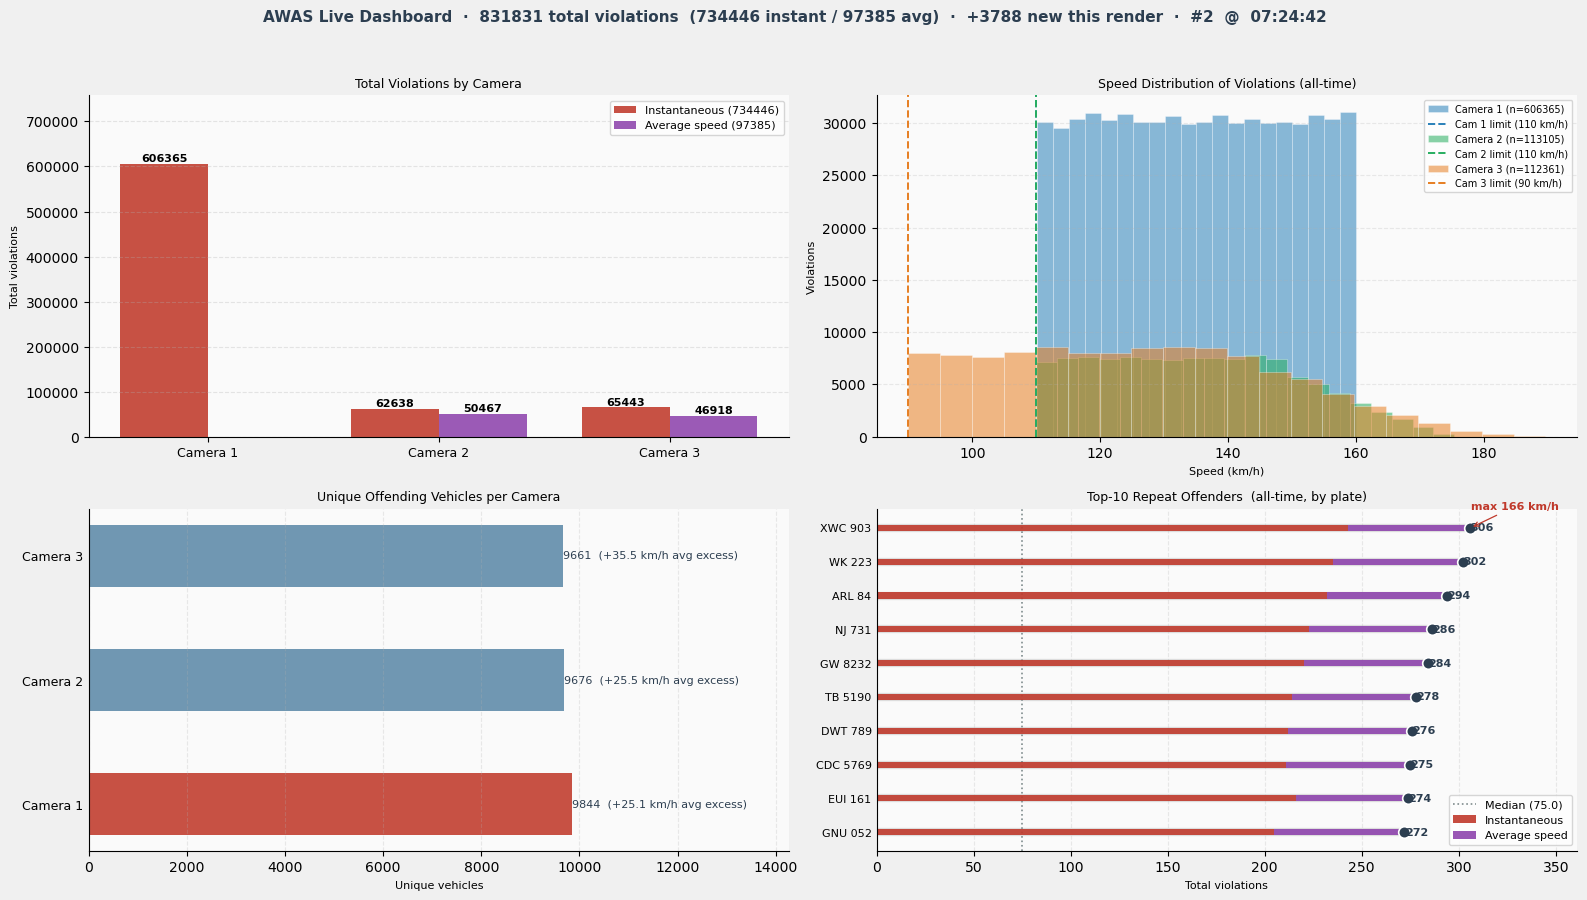

[Batch 57] [avg_ab]: 6 op(s) — upserted: 0, modified: 0
[Batch 75] [camera_a_instant]: 40 op(s) — upserted: 0, modified: 0
[Batch 74] [camera_c_instant]: 3 op(s) — upserted: 0, modified: 0
[Batch 77] [camera_b_instant]: 1 op(s) — upserted: 0, modified: 0
[2026-05-25 07:24:45] [Segment A→B] Batch 28: 9 matched pair(s).
[Batch 57] [avg_bc]: 5 op(s) — upserted: 0, modified: 0
[Batch 58] [avg_ab]: 1 op(s) — upserted: 0, modified: 0
+---------+---------------+-------------+--------------+-------------+--------------------------+--------------------------+--------------+-------------+-----------+------+--------------+---------------+-------------+--------------+
|car_plate|start_camera_id|end_camera_id|entry_batch_id|exit_batch_id|entry_time                |exit_time                 |entry_position|exit_position|speed_limit|source|entry_latitude|entry_longitude|exit_latitude|exit_longitude|
+---------+---------------+-------------+--------------+-------------+--------------------------+-----

[Batch 81] [camera_b_instant]: 4 op(s) — upserted: 0, modified: 0[Batch 79] [camera_a_instant]: 20 op(s) — upserted: 0, modified: 0

[Batch 78] [camera_c_instant]: 2 op(s) — upserted: 0, modified: 0
[Batch 60] [avg_bc]: 2 op(s) — upserted: 0, modified: 0
+---------+---------------+-------------+--------------+-------------+-------------------+--------------------------+--------------+-------------+-----------+------+--------------+---------------+-------------+--------------+
|car_plate|start_camera_id|end_camera_id|entry_batch_id|exit_batch_id|entry_time         |exit_time                 |entry_position|exit_position|speed_limit|source|entry_latitude|entry_longitude|exit_latitude|exit_longitude|
+---------+---------------+-------------+--------------+-------------+-------------------+--------------------------+--------------+-------------+-----------+------+--------------+---------------+-------------+--------------+
|TAK 3    |1              |2            |28            |288        

[Batch 85] [camera_b_instant]: 2 op(s) — upserted: 0, modified: 0
[Batch 82] [camera_c_instant]: 4 op(s) — upserted: 0, modified: 0
[Batch 83] [camera_a_instant]: 38 op(s) — upserted: 0, modified: 0
[2026-05-25 07:25:08] [Segment B→C] Batch 30: 7 matched pair(s).
[Batch 63] [avg_bc]: 6 op(s) — upserted: 0, modified: 0
[Batch 64] [avg_ab]: 3 op(s) — upserted: 0, modified: 0
[Batch 86] [camera_b_instant]: 2 op(s) — upserted: 0, modified: 0
[2026-05-25 07:25:10] [Segment A→B] Batch 31: 6 matched pair(s).
[Batch 83] [camera_c_instant]: 2 op(s) — upserted: 0, modified: 0
[Batch 84] [camera_a_instant]: 29 op(s) — upserted: 0, modified: 0
[Batch 65] [avg_ab]: 2 op(s) — upserted: 0, modified: 0
[Batch 64] [avg_bc]: 3 op(s) — upserted: 0, modified: 0
+---------+---------------+-------------+--------------+-------------+--------------------------+--------------------------+--------------+-------------+-----------+------+--------------+---------------+-------------+--------------+
|car_plate|star

In [14]:
# Re-run this cell to refresh the dashboard.
print("Rendering dashboard")
render_dashboard()